# Signature Verification — ResNet-50 ONLY (2 / 3 / 6 / 10-Reference Zero-Shot Eval)

Loads the already-trained ResNet-50 checkpoint from Drive (no Swin-Tiny, no
fusion). Training loop is included but **commented out** — weights are
already saved, this notebook is eval-only by default.


In [1]:
# 1. Setup
!pip -q install kagglehub

import os, gc, re, json, time, random
from pathlib import Path
import cv2, numpy as np, pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
if DEVICE.type=="cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory/1024**3,2),"GB")
os.environ["PYTORCH_CUDA_ALLOC_CONF"]="expandable_segments:True"
torch.backends.cudnn.benchmark=True

IMAGE_SIZE=224
BATCH_RESNET=24
NUM_WORKERS=2
EMBED_DIM=256
MAX_EPOCHS=20
PATIENCE=5
PAIR_SAMPLES=12000
TRIPLET_SAMPLES=6000
AMP=DEVICE.type=="cuda"

from google.colab import drive
drive.mount("/content/drive")

ROOT=Path("/content/drive/MyDrive/signature_verification_final")
RESNET_DIR=ROOT/"resnet50"; RESULTS_DIR=ROOT/"results"
for p in [RESNET_DIR,RESULTS_DIR]: p.mkdir(parents=True,exist_ok=True)
print("Project:",ROOT)


DEVICE: cuda
GPU: Tesla T4
VRAM: 14.56 GB
Mounted at /content/drive
Project: /content/drive/MyDrive/signature_verification_final


## 2. Download and verify Akash + Robin — via Kaggle API using Colab Secrets

In [2]:
# 2. Download and verify Akash + Robin — via Kaggle API using Colab Secrets
import os, shutil
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

!pip -q install kaggle

AKASH_SLUG = "akashgundu/signature-verification-dataset"
ROBIN_SLUG = "robinreni/signature-verification-dataset"

akash_root = Path("/content/akash_data").resolve()
robin_root = Path("/content/robin_data").resolve()

for p in [akash_root, robin_root]:
    if p.exists():
        shutil.rmtree(p)
    p.mkdir(parents=True, exist_ok=True)

!kaggle datasets download -d {AKASH_SLUG} -p {akash_root} --unzip
!kaggle datasets download -d {ROBIN_SLUG} -p {robin_root} --unzip

print("Akash:", akash_root)
print("Robin:", robin_root)

if akash_root == robin_root:
    raise RuntimeError("STOP: paths identical (shouldn't happen with explicit dirs).")

akash_count = sum(1 for _ in akash_root.rglob("*") if _.is_file())
robin_count = sum(1 for _ in robin_root.rglob("*") if _.is_file())
print("Akash files:", akash_count)
print("Robin files:", robin_count)

if akash_count == 0 or robin_count == 0:
    raise RuntimeError("STOP: one of the downloads is empty — check KAGGLE_USERNAME/KAGGLE_KEY.")


Dataset URL: https://www.kaggle.com/datasets/akashgundu/signature-verification-dataset
License(s): unknown
100% 98.2M/98.2M [00:00<00:00, 109MB/s]

Dataset URL: https://www.kaggle.com/datasets/robinreni/signature-verification-dataset
License(s): CC0-1.0
100% 601M/601M [00:04<00:00, 154MB/s]

Akash: /content/akash_data
Robin: /content/robin_data
Akash files: 14628
Robin files: 4302


## 3. Build manifests + hard sanity checks

In [3]:
EXT={".png",".jpg",".jpeg",".bmp",".tif",".tiff"}

def build_manifest(root,source):
    rows=[]
    for d in sorted(root.rglob("*")):
        if not d.is_dir() or not d.name.isdigit(): continue
        forg=d.with_name(d.name+"_forg")
        if not forg.is_dir(): continue
        wid=f"{source}_{d.name}"
        for p in sorted(d.iterdir()):
            if p.suffix.lower() in EXT:
                rows.append({"writer_id":wid,"path":str(p),"label":1,"source":source})
        for p in sorted(forg.iterdir()):
            if p.suffix.lower() in EXT:
                rows.append({"writer_id":wid,"path":str(p),"label":0,"source":source})
    return pd.DataFrame(rows)

akash_df=build_manifest(akash_root,"akash")
robin_df=build_manifest(robin_root,"robin")
source_df=pd.concat([akash_df,robin_df],ignore_index=True)

print("Akash:",len(akash_df),"images /",akash_df.writer_id.nunique(),"writers")
print("Robin:",len(robin_df),"images /",robin_df.writer_id.nunique(),"writers")
print("Combined:",len(source_df),"images /",source_df.writer_id.nunique(),"writers")

if len(source_df)<15000 or source_df.writer_id.nunique()<500:
    raise RuntimeError(f"STOP: unexpected source size: {len(source_df)} images, {source_df.writer_id.nunique()} writers. Expected roughly 18,900 images / 750 writers.")
if source_df.path.duplicated().sum():
    raise RuntimeError("STOP: duplicate image paths detected.")
print("SOURCE MANIFEST PASSED.")


Akash: 14626 images / 686 writers
Robin: 4298 images / 64 writers
Combined: 18924 images / 750 writers
SOURCE MANIFEST PASSED.


## 4. Writer-disjoint 80/10/10 split

In [4]:
def writer_split(df,seed=SEED):
    writers=np.array(sorted(df.writer_id.unique()))
    rng=np.random.default_rng(seed); rng.shuffle(writers)
    n=len(writers); ntr=int(.8*n); nv=int(.1*n)
    tr=set(writers[:ntr]); va=set(writers[ntr:ntr+nv]); te=set(writers[ntr+nv:])
    return tuple(df[df.writer_id.isin(s)].reset_index(drop=True) for s in [tr,va,te])

train_df,val_df,test_df=writer_split(source_df)
print("Train:",len(train_df),train_df.writer_id.nunique(),"writers")
print("Val:",len(val_df),val_df.writer_id.nunique(),"writers")
print("Test:",len(test_df),test_df.writer_id.nunique(),"writers")
assert set(train_df.writer_id).isdisjoint(val_df.writer_id)
assert set(train_df.writer_id).isdisjoint(test_df.writer_id)
assert set(val_df.writer_id).isdisjoint(test_df.writer_id)


Train: 15199 600 writers
Val: 1881 75 writers
Test: 1844 75 writers


## 5. Preprocessing

In [5]:
# 5. Preprocessing
def load_signature(path):
    x=cv2.imread(str(path),cv2.IMREAD_GRAYSCALE)
    if x is None: raise ValueError(f"Cannot read {path}")
    _,b=cv2.threshold(x,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    ink=cv2.findNonZero(255-b)
    if ink is not None:
        xx,yy,w,h=cv2.boundingRect(ink); pad=max(3,int(.05*max(w,h)))
        x=x[max(0,yy-pad):min(x.shape[0],yy+h+pad),max(0,xx-pad):min(x.shape[1],xx+w+pad)]
    h,w=x.shape; scale=min(IMAGE_SIZE/max(w,1),IMAGE_SIZE/max(h,1))
    nw=max(1,int(round(w*scale))); nh=max(1,int(round(h*scale)))
    r=cv2.resize(x,(nw,nh),interpolation=cv2.INTER_AREA)
    canvas=np.full((IMAGE_SIZE,IMAGE_SIZE),255,np.uint8)
    canvas[(IMAGE_SIZE-nh)//2:(IMAGE_SIZE-nh)//2+nh,(IMAGE_SIZE-nw)//2:(IMAGE_SIZE-nw)//2+nw]=r
    return (1.0-canvas.astype(np.float32)/255.0).astype(np.float32)

train_aug=transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomAffine(degrees=5,translate=(.03,.03),scale=(.97,1.03),shear=2),
    transforms.ToTensor()
])
eval_tf=transforms.ToTensor()


## 6. Pair/triplet datasets (only needed if you uncomment training below)

In [6]:
class PairDataset(Dataset):
    def __init__(self,df,n=PAIR_SAMPLES,seed=SEED):
        self.df=df.reset_index(drop=True); self.n=n
        self.rng=np.random.default_rng(seed)
        self.by={w:g for w,g in df.groupby("writer_id")}
        self.writers=list(self.by)
    def __len__(self): return self.n
    def genuine(self,w):
        g=self.by[w]; return g[g.label==1].iloc[self.rng.integers(len(g))]
    def __getitem__(self,i):
        w=self.rng.choice(self.writers); a=self.genuine(w)
        if i%2==0:
            b=self.genuine(w); y=1.
        else:
            f=self.by[w][self.by[w].label==0]
            if len(f): b=f.iloc[self.rng.integers(len(f))]
            else:
                ow=self.rng.choice([x for x in self.writers if x!=w]); b=self.genuine(ow)
            y=0.
        return train_aug(load_signature(a.path)),train_aug(load_signature(b.path)),torch.tensor(y,dtype=torch.float32)

class TripletDataset(Dataset):
    def __init__(self,df,n=TRIPLET_SAMPLES,seed=SEED):
        self.n=n; self.rng=np.random.default_rng(seed)
        self.by={w:g[g.label==1].copy() for w,g in df.groupby("writer_id")}
        self.writers=[w for w,g in self.by.items() if len(g)>=2]
    def __len__(self): return self.n
    def __getitem__(self,i):
        w=self.rng.choice(self.writers); nw=self.rng.choice([x for x in self.writers if x!=w])
        g=self.by[w]; ng=self.by[nw]
        a=g.iloc[self.rng.integers(len(g))]; p=g.iloc[self.rng.integers(len(g))]; n=ng.iloc[self.rng.integers(len(ng))]
        return train_aug(load_signature(a.path)),train_aug(load_signature(p.path)),train_aug(load_signature(n.path))


In [15]:
class PairDataset(Dataset):
    def __init__(self,df,n=PAIR_SAMPLES,seed=SEED):
        self.df=df.reset_index(drop=True); self.n=n
        self.rng=np.random.default_rng(seed)
        self.by={w:g for w,g in df.groupby("writer_id")}
        self.writers=list(self.by)
    def __len__(self): return self.n
    def genuine(self,w):
        g=self.by[w]; gen=g[g.label==1]
        return gen.iloc[self.rng.integers(len(gen))]   # <-- fixed: len(gen), not len(g)
    def __getitem__(self,i):
        w=self.rng.choice(self.writers); a=self.genuine(w)
        if i%2==0:
            b=self.genuine(w); y=1.
        else:
            f=self.by[w][self.by[w].label==0]
            if len(f): b=f.iloc[self.rng.integers(len(f))]
            else:
                ow=self.rng.choice([x for x in self.writers if x!=w]); b=self.genuine(ow)
            y=0.
        return train_aug(load_signature(a.path)),train_aug(load_signature(b.path)),torch.tensor(y,dtype=torch.float32)

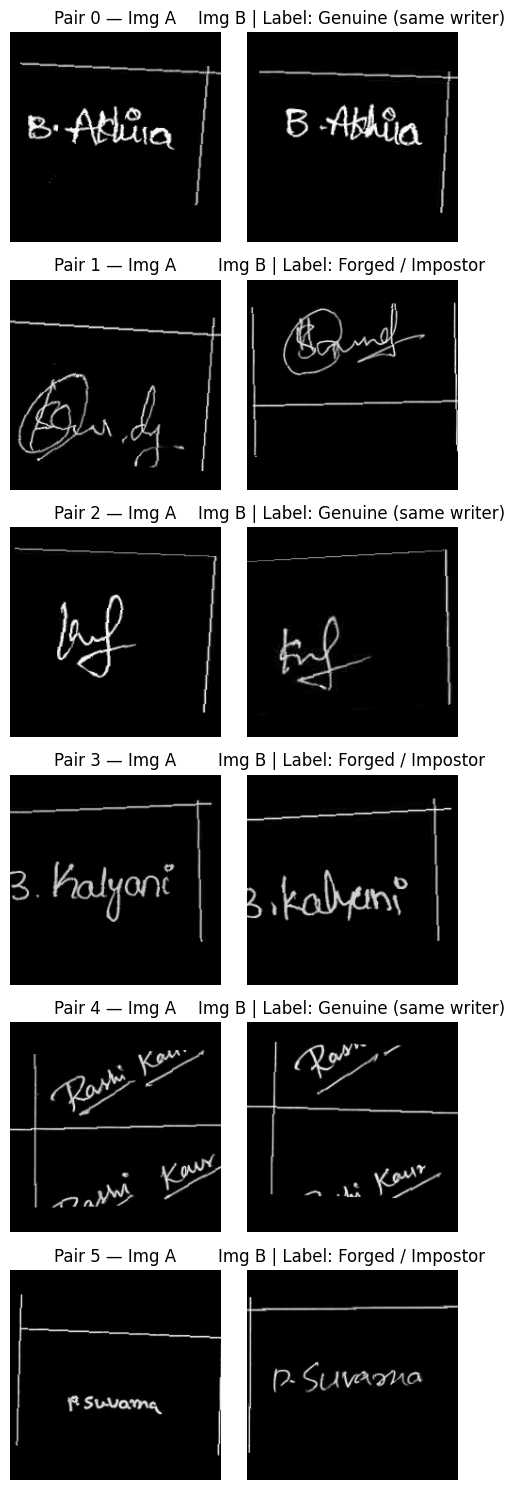

In [16]:
pair_ds = PairDataset(train_df, n=200, seed=SEED)
show_pairs(pair_ds, n=6)

## Writer Disjoint

In [12]:
train_writers = set(train_df.writer_id)
val_writers   = set(val_df.writer_id)
test_writers  = set(test_df.writer_id)

print("Train writers ∩ Validation writers =", len(train_writers & val_writers))
print("Train writers ∩ Test writers =", len(train_writers & test_writers))
print("Validation writers ∩ Test writers =", len(val_writers & test_writers))

Train writers ∩ Validation writers = 0
Train writers ∩ Test writers = 0
Validation writers ∩ Test writers = 0


## 7. Model — ResNet-50 only

In [7]:
# 7. Model — ResNet-50 only
class ResNet50Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        b=models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        old=b.conv1
        c=nn.Conv2d(1,old.out_channels,old.kernel_size,old.stride,old.padding,bias=False)
        with torch.no_grad(): c.weight.copy_(old.weight.mean(1,keepdim=True))
        b.conv1=c; inf=b.fc.in_features; b.fc=nn.Identity()
        self.backbone=b
        self.proj=nn.Sequential(nn.Linear(inf,512),nn.ReLU(),nn.Dropout(.2),nn.Linear(512,EMBED_DIM))
    def forward(self,x): return F.normalize(self.proj(self.backbone(x)),p=2,dim=1)

def contrastive(z1,z2,y,margin=1.0):
    d=F.pairwise_distance(z1,z2)
    return (y*d.pow(2)+(1-y)*F.relu(margin-d).pow(2)).mean()

def triplet(a,p,n):
    return F.triplet_margin_loss(a,p,n,margin=.3,p=2)

class ImgDS(Dataset):
    def __init__(self,df): self.df=df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]; return eval_tf(load_signature(r.path)),int(r.label),r.writer_id

@torch.no_grad()
def embeddings(model,df,bs):
    model.eval(); out=[]
    dl=DataLoader(ImgDS(df),batch_size=bs,shuffle=False,num_workers=NUM_WORKERS,pin_memory=True)
    for x,_,_ in dl: out.append(model(x.to(DEVICE,non_blocking=True)).cpu().numpy())
    return np.concatenate(out)

def make_ref_query(df,nref,seed=SEED):
    rng=np.random.default_rng(seed); refs=[]; qs=[]
    for w,g in df.groupby("writer_id"):
        gen=g[g.label==1].copy(); forg=g[g.label==0].copy()
        if len(gen)<=nref: continue
        idx=np.array(gen.index); rng.shuffle(idx)
        refs.append(gen.loc[idx[:nref]]); qs.append(gen.loc[idx[nref:]])
        if len(forg): qs.append(forg)
    return pd.concat(refs,ignore_index=True),pd.concat(qs,ignore_index=True)

def distances(ref_df,ref_z,q_df,q_z):
    centers={}
    for w,g in ref_df.groupby("writer_id"):
        idx=g.index.to_numpy(); centers[w]=ref_z[idx].mean(0)
    d=np.array([np.linalg.norm(z-centers[w]) for z,w in zip(q_z,q_df.writer_id)])
    return d,q_df.label.to_numpy()

def threshold(d,y):
    best=(-1,None)
    for t in np.unique(d):
        p=(d<=t).astype(int); b=balanced_accuracy_score(y,p)
        if b>best[0]: best=(b,float(t))
    return best[1]

def metrics(d,y,t):
    p=(d<=t).astype(int); gen=y==1; forg=y==0
    return dict(
        accuracy=float(accuracy_score(y,p)),
        balanced_accuracy=float(balanced_accuracy_score(y,p)),
        FAR=float(((p==1)&forg).sum()/max(1,forg.sum())),
        FRR=float(((p==0)&gen).sum()/max(1,gen.sum())),
        AUC=float(roc_auc_score(y,-d)),
        threshold=float(t)
    )


## 8. T4-safe training function (COMMENTED OUT — weights already saved)

Function is kept defined in case you ever need to retrain, but the actual
call is commented out. This notebook loads the existing `best.pt` from
Drive instead (Section 9).

In [ ]:
# def train_backbone(model,name,outdir,bs,epochs=MAX_EPOCHS):
#     model.to(DEVICE)
#     opt=torch.optim.AdamW(model.parameters(),lr=1e-4,weight_decay=1e-4)
#     scaler=torch.amp.GradScaler("cuda",enabled=AMP)
#     pair_loader=DataLoader(PairDataset(train_df),batch_size=bs,num_workers=NUM_WORKERS,pin_memory=True)
#     tri_loader=DataLoader(TripletDataset(train_df),batch_size=bs,num_workers=NUM_WORKERS,pin_memory=True)
#     best=-1; best_state=None; wait=0
#     for ep in range(1,epochs+1):
#         st=time.time(); model.train(); it=iter(tri_loader); losses=[]
#         for x1,x2,y in pair_loader:
#             try: xa,xp,xn=next(it)
#             except StopIteration: it=iter(tri_loader); xa,xp,xn=next(it)
#             x1=x1.to(DEVICE); x2=x2.to(DEVICE); y=y.to(DEVICE); xa=xa.to(DEVICE); xp=xp.to(DEVICE); xn=xn.to(DEVICE)
#             opt.zero_grad(set_to_none=True)
#             with torch.amp.autocast("cuda",enabled=AMP):
#                 z1=model(x1); z2=model(x2); za=model(xa); zp=model(xp); zn=model(xn)
#                 loss=contrastive(z1,z2,y)+.5*triplet(za,zp,zn)
#             scaler.scale(loss).backward(); scaler.unscale_(opt)
#             torch.nn.utils.clip_grad_norm_(model.parameters(),5.)
#             scaler.step(opt); scaler.update(); losses.append(float(loss.detach().cpu()))
#         vr,vq=make_ref_query(val_df,2,SEED)
#         vd,vy=distances(vr,embeddings(model,vr,bs),vq,embeddings(model,vq,bs))
#         t=threshold(vd,vy); m=metrics(vd,vy,t)
#         print(f"{name} Epoch {ep:02d}/{epochs} | loss={np.mean(losses):.4f} | val_acc={m['accuracy']:.2%} | val_bal={m['balanced_accuracy']:.2%} | FAR={m['FAR']:.2%} | FRR={m['FRR']:.2%} | AUC={m['AUC']:.4f} | time={(time.time()-st)/60:.1f}m")
#         if m["balanced_accuracy"]>best:
#             best=m["balanced_accuracy"]; wait=0
#             best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
#             torch.save(best_state,outdir/"best.pt"); json.dump(m,open(outdir/"best_metrics.json","w"),indent=2)
#             print(">>> NEW BEST",name,"CHECKPOINT SAVED")
#         else:
#             wait+=1
#             if wait>=PATIENCE: print("Early stopping",name); break
#         gc.collect()
#         if DEVICE.type=="cuda": torch.cuda.empty_cache()
#     model.load_state_dict(best_state); model.to(DEVICE).eval()
#     return model

# # ------------------------------------------------------------------
# # TRAINING CALL — COMMENTED OUT. Weights already saved to Drive.
# # Uncomment only if you need to retrain from scratch.
# # ------------------------------------------------------------------
# # resnet_model = train_backbone(ResNet50Encoder(), "ResNet-50", RESNET_DIR, BATCH_RESNET)


## 9. Load saved ResNet-50 weights from Google Drive

In [8]:
# ============================================================
# LOAD SAVED RESNET-50 FROM GOOGLE DRIVE
# ============================================================

resnet_model = ResNet50Encoder().to(DEVICE)

resnet_path = RESNET_DIR / "best.pt"

if not resnet_path.exists():
    raise FileNotFoundError(f"ResNet checkpoint not found:\n{resnet_path}")

resnet_state = torch.load(resnet_path, map_location=DEVICE)
resnet_model.load_state_dict(resnet_state)
resnet_model.eval()

print("✅ ResNet-50 loaded from Drive")
print("Checkpoint:", resnet_path)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 99.1MB/s]


✅ ResNet-50 loaded from Drive
Checkpoint: /content/drive/MyDrive/signature_verification_final/resnet50/best.pt


## 10. Download and build CEDAR manifest

In [9]:
!pip install kagglehub
import kagglehub

cedar_root=Path(kagglehub.dataset_download("shreelakshmigp/cedardataset"))
org=list(cedar_root.rglob("full_org"))[0]
forg=list(cedar_root.rglob("full_forg"))[0]

rows=[]
for p in org.iterdir():
    m=re.match(r"original_(\d+)_(\d+)",p.stem)
    if p.suffix.lower() in EXT and m: rows.append({"writer_id":f"cedar_{m.group(1)}","path":str(p),"label":1})
for p in forg.iterdir():
    m=re.match(r"forgeries_(\d+)_(\d+)",p.stem)
    if p.suffix.lower() in EXT and m: rows.append({"writer_id":f"cedar_{m.group(1)}","path":str(p),"label":0})
cedar_df=pd.DataFrame(rows)
print("CEDAR:",len(cedar_df),"images /",cedar_df.writer_id.nunique(),"writers")


100%|██████████| 242M/242M [00:01<00:00, 137MB/s]

Extracting files...


CEDAR: 2640 images / 55 writers


## 11. Official zero-shot evaluation — 2, 3, 6, AND 10 references (ONE combined cell)

Threshold is always selected from Akash+Robin validation, never from CEDAR
— no threshold leakage. All four reference counts run in a single loop.

In [11]:
# Threshold is ALWAYS selected from Akash+Robin validation, never CEDAR.

def eval_mode(model, name, nref, bs):
    vr, vq = make_ref_query(val_df, nref, SEED)
    vd, vy = distances(vr, embeddings(model, vr, bs), vq, embeddings(model, vq, bs))
    t = threshold(vd, vy)

    cr, cq = make_ref_query(cedar_df, nref, SEED)
    cd, cy = distances(cr, embeddings(model, cr, bs), cq, embeddings(model, cq, bs))
    m = metrics(cd, cy, t)
    m.update({"model": name, "references": nref})
    return m

REFERENCE_COUNTS = [2, 3, 6, 10]

results = []
for nref in REFERENCE_COUNTS:
    m = eval_mode(resnet_model, "ResNet-50", nref, BATCH_RESNET)
    results.append(m)
    print(f"\nResNet-50 | {nref} references")
    print(f"Accuracy: {m['accuracy']:.2%}")
    print(f"Balanced Accuracy: {m['balanced_accuracy']:.2%}")
    print(f"FAR: {m['FAR']:.2%}")
    print(f"FRR: {m['FRR']:.2%}")
    print(f"AUC: {m['AUC']:.4f}")
    print(f"Threshold: {m['threshold']:.6f}")

results_df = pd.DataFrame(results)
display(results_df[["model", "references", "accuracy", "balanced_accuracy", "FAR", "FRR", "AUC", "threshold"]])



ResNet-50 | 2 references
Accuracy: 79.76%
Balanced Accuracy: 79.19%
FAR: 7.58%
FRR: 34.05%
AUC: 0.9107
Threshold: 0.343098

ResNet-50 | 3 references
Accuracy: 81.54%
Balanced Accuracy: 80.53%
FAR: 4.39%
FRR: 34.55%
AUC: 0.9288
Threshold: 0.311824

ResNet-50 | 6 references
Accuracy: 85.32%
Balanced Accuracy: 83.61%
FAR: 4.39%
FRR: 28.38%
AUC: 0.9360
Threshold: 0.309600

ResNet-50 | 10 references
Accuracy: 87.42%
Balanced Accuracy: 86.66%
FAR: 10.45%
FRR: 16.23%
AUC: 0.9385
Threshold: 0.351160


,model,references,accuracy,balanced_accuracy,FAR,FRR,AUC,threshold
0,ResNet-50,2,0.797628,0.791873,0.075758,0.340496,0.910687,0.343098
1,ResNet-50,3,0.815354,0.805303,0.043939,0.345455,0.928757,0.311824
2,ResNet-50,6,0.853247,0.836111,0.043939,0.283838,0.936001,0.309600
3,ResNet-50,10,0.874163,0.866558,0.104545,0.162338,0.938492,0.351160


## All FP Cases

## With 2 Refrences

Total FP cases: 100 out of 1320 forged samples
FAR (False Positive Rate): 7.58%


,writer_id,path,distance,threshold
26,cedar_1,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.325949,0.343098
484,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.301457,0.343098
486,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.301701,0.343098
491,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.239712,0.343098
501,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.233773,0.343098
...,...,...,...,...
2112,cedar_50,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.301917,0.343098
2185,cedar_52,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.342237,0.343098
2191,cedar_52,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.321677,0.343098
2194,cedar_52,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.333904,0.343098


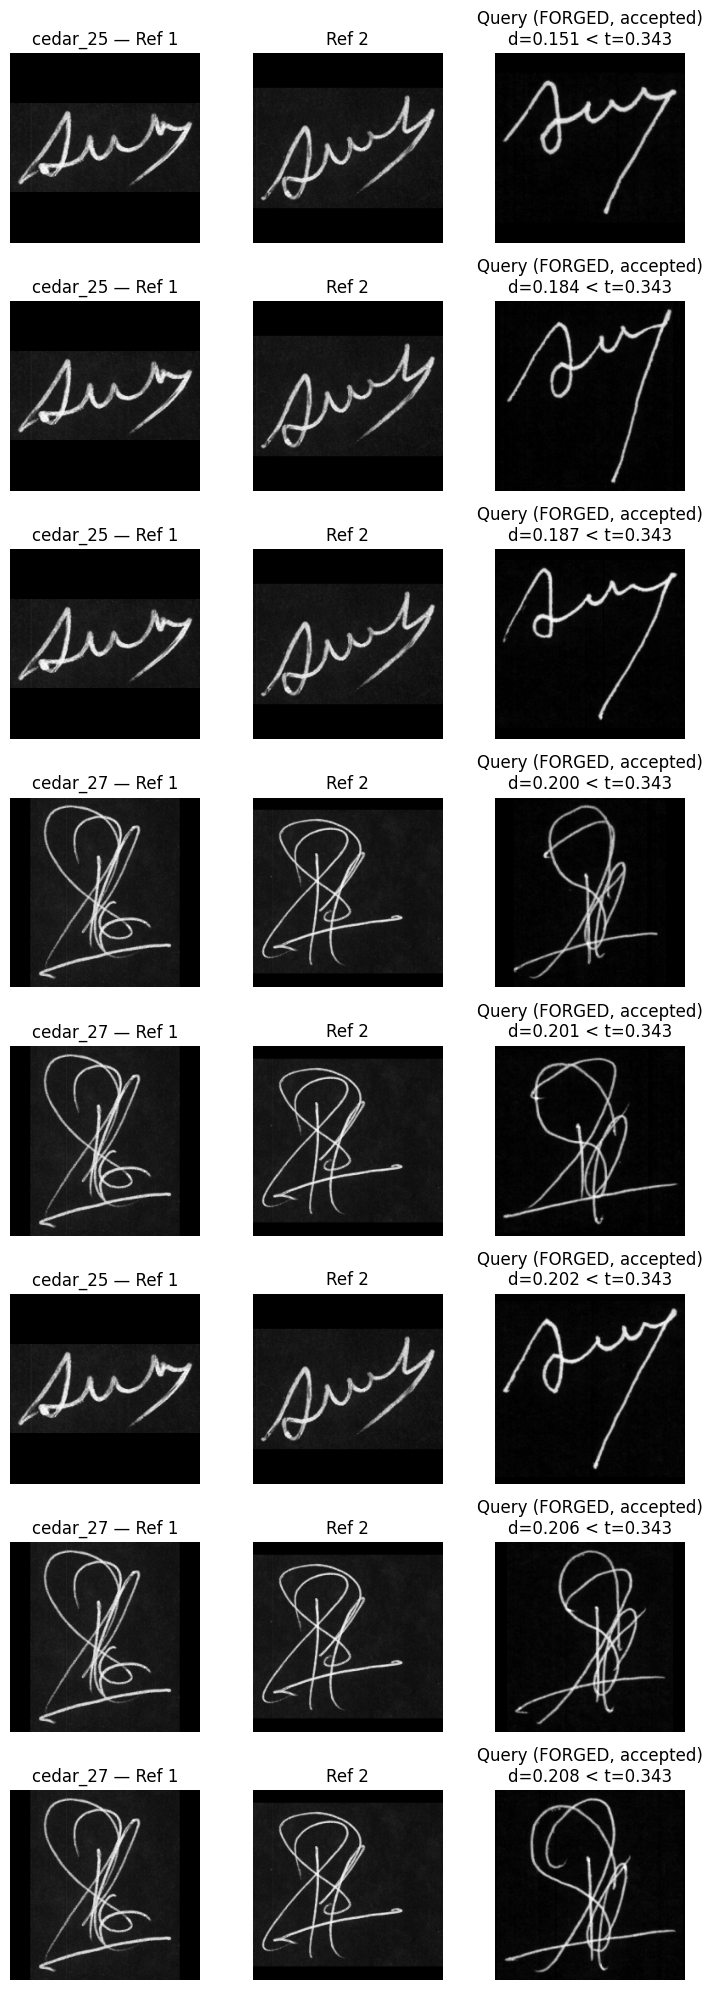

In [19]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Compute FP cases (2-reference protocol, threshold from val only)
# ------------------------------------------------------------------
nref = 2

val_ref, val_query = make_ref_query(val_df, nref, SEED)
val_dist, val_labels = distances(
    val_ref, embeddings(resnet_model, val_ref, BATCH_RESNET),
    val_query, embeddings(resnet_model, val_query, BATCH_RESNET)
)
t = threshold(val_dist, val_labels)

cedar_ref, cedar_query = make_ref_query(cedar_df, nref, SEED)
cedar_dist, cedar_labels = distances(
    cedar_ref, embeddings(resnet_model, cedar_ref, BATCH_RESNET),
    cedar_query, embeddings(resnet_model, cedar_query, BATCH_RESNET)
)

pred = (cedar_dist <= t).astype(int)
fp_mask = (pred == 1) & (cedar_labels == 0)
fp_indices = np.where(fp_mask)[0]

fp_df = cedar_query.reset_index(drop=True).iloc[fp_indices].copy()
fp_df["distance"] = cedar_dist[fp_indices]
fp_df["threshold"] = t

n_forged = int((cedar_labels == 0).sum())
print(f"Total FP cases: {len(fp_df)} out of {n_forged} forged samples")
print(f"FAR (False Positive Rate): {len(fp_df)/max(1,n_forged):.2%}")
display(fp_df[["writer_id", "path", "distance", "threshold"]])

# ------------------------------------------------------------------
# 2. Visualize: Ref 1 | Ref 2 | Query (forged, wrongly accepted)
# ------------------------------------------------------------------
fp_sorted = fp_df.sort_values("distance").reset_index(drop=True)
n = min(8, len(fp_sorted))

if n == 0:
    print("No FP cases to visualize.")
else:
    fig, axes = plt.subplots(n, 3, figsize=(7.5, 2.5*n))
    if n == 1: axes = axes.reshape(1, -1)

    for i in range(n):
        row = fp_sorted.iloc[i]
        refs = cedar_ref[cedar_ref.writer_id == row.writer_id]
        r1_img = load_signature(refs.iloc[0].path)
        r2_img = load_signature(refs.iloc[1].path)
        query_img = load_signature(row.path)

        axes[i,0].imshow(r1_img, cmap="gray"); axes[i,0].set_title(f"{row.writer_id} — Ref 1"); axes[i,0].axis("off")
        axes[i,1].imshow(r2_img, cmap="gray"); axes[i,1].set_title("Ref 2"); axes[i,1].axis("off")
        axes[i,2].imshow(query_img, cmap="gray")
        axes[i,2].set_title(f"Query (FORGED, accepted)\nd={row.distance:.3f} < t={row.threshold:.3f}")
        axes[i,2].axis("off")

    plt.tight_layout(); plt.show()

## With 3 Refrences

Total FP cases: 58 out of 1320 forged samples
FAR (False Positive Rate): 4.39%


,writer_id,path,distance,threshold
473,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.299503,0.311824
475,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.250817,0.311824
476,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.308781,0.311824
480,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.235035,0.311824
487,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.285207,0.311824
488,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.303199,0.311824
490,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.239391,0.311824
491,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.218006,0.311824
492,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.257757,0.311824
493,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.172819,0.311824


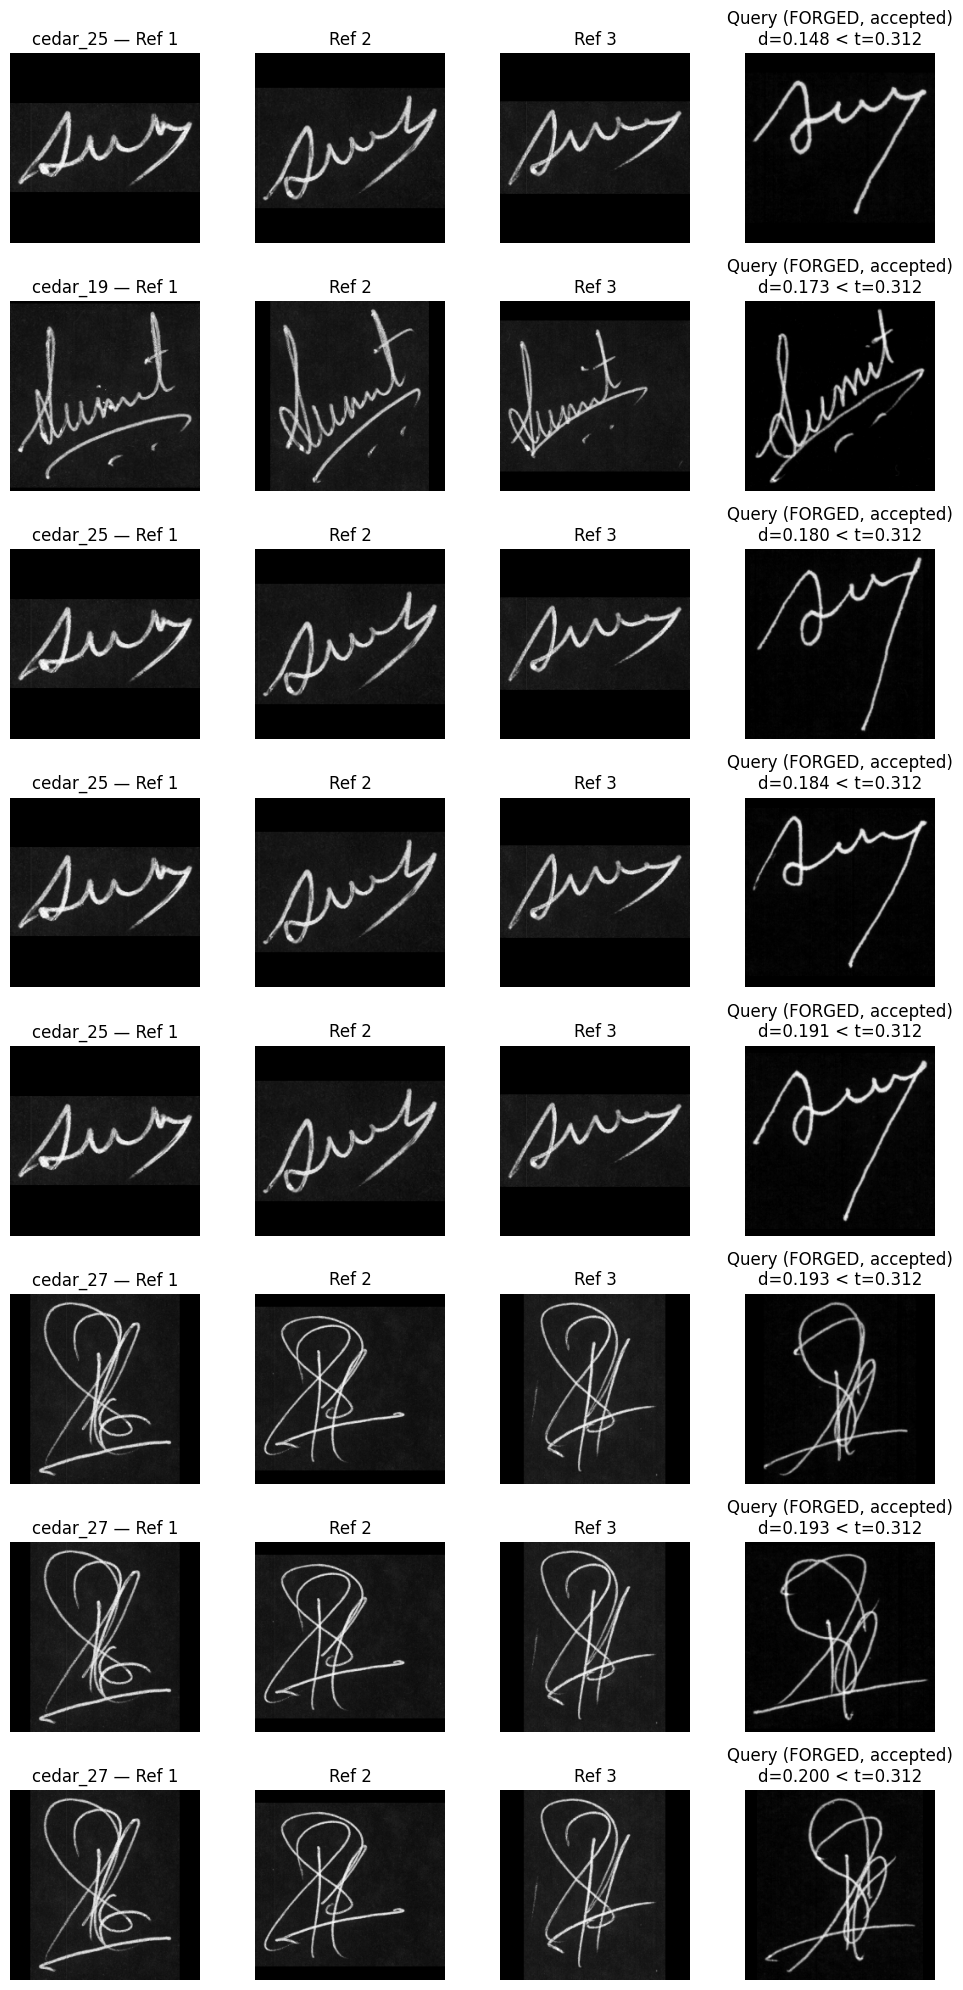

In [20]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Compute FP cases (3-reference protocol, threshold from val only)
# ------------------------------------------------------------------
nref = 3

val_ref, val_query = make_ref_query(val_df, nref, SEED)
val_dist, val_labels = distances(
    val_ref, embeddings(resnet_model, val_ref, BATCH_RESNET),
    val_query, embeddings(resnet_model, val_query, BATCH_RESNET)
)
t = threshold(val_dist, val_labels)

cedar_ref, cedar_query = make_ref_query(cedar_df, nref, SEED)
cedar_dist, cedar_labels = distances(
    cedar_ref, embeddings(resnet_model, cedar_ref, BATCH_RESNET),
    cedar_query, embeddings(resnet_model, cedar_query, BATCH_RESNET)
)

pred = (cedar_dist <= t).astype(int)
fp_mask = (pred == 1) & (cedar_labels == 0)
fp_indices = np.where(fp_mask)[0]

fp_df = cedar_query.reset_index(drop=True).iloc[fp_indices].copy()
fp_df["distance"] = cedar_dist[fp_indices]
fp_df["threshold"] = t

n_forged = int((cedar_labels == 0).sum())
print(f"Total FP cases: {len(fp_df)} out of {n_forged} forged samples")
print(f"FAR (False Positive Rate): {len(fp_df)/max(1,n_forged):.2%}")
display(fp_df[["writer_id", "path", "distance", "threshold"]])

# ------------------------------------------------------------------
# 2. Visualize: Ref 1 | Ref 2 | Ref 3 | Query (forged, wrongly accepted)
# ------------------------------------------------------------------
fp_sorted = fp_df.sort_values("distance").reset_index(drop=True)
n = min(8, len(fp_sorted))

if n == 0:
    print("No FP cases to visualize.")
else:
    fig, axes = plt.subplots(n, 4, figsize=(10, 2.5*n))
    if n == 1: axes = axes.reshape(1, -1)

    for i in range(n):
        row = fp_sorted.iloc[i]
        refs = cedar_ref[cedar_ref.writer_id == row.writer_id]
        r1_img = load_signature(refs.iloc[0].path)
        r2_img = load_signature(refs.iloc[1].path)
        r3_img = load_signature(refs.iloc[2].path)
        query_img = load_signature(row.path)

        axes[i,0].imshow(r1_img, cmap="gray"); axes[i,0].set_title(f"{row.writer_id} — Ref 1"); axes[i,0].axis("off")
        axes[i,1].imshow(r2_img, cmap="gray"); axes[i,1].set_title("Ref 2"); axes[i,1].axis("off")
        axes[i,2].imshow(r3_img, cmap="gray"); axes[i,2].set_title("Ref 3"); axes[i,2].axis("off")
        axes[i,3].imshow(query_img, cmap="gray")
        axes[i,3].set_title(f"Query (FORGED, accepted)\nd={row.distance:.3f} < t={row.threshold:.3f}")
        axes[i,3].axis("off")

    plt.tight_layout(); plt.show()

## With 6 Refrences

Total FP cases: 58 out of 1320 forged samples
FAR (False Positive Rate): 4.39%


,writer_id,path,distance,threshold
22,cedar_1,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.295247,0.3096
440,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.290678,0.3096
442,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.275286,0.3096
447,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.224784,0.3096
457,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.224086,0.3096
458,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.252756,0.3096
459,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.275221,0.3096
460,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.184648,0.3096
503,cedar_2,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.306949,0.3096
585,cedar_21,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.286440,0.3096


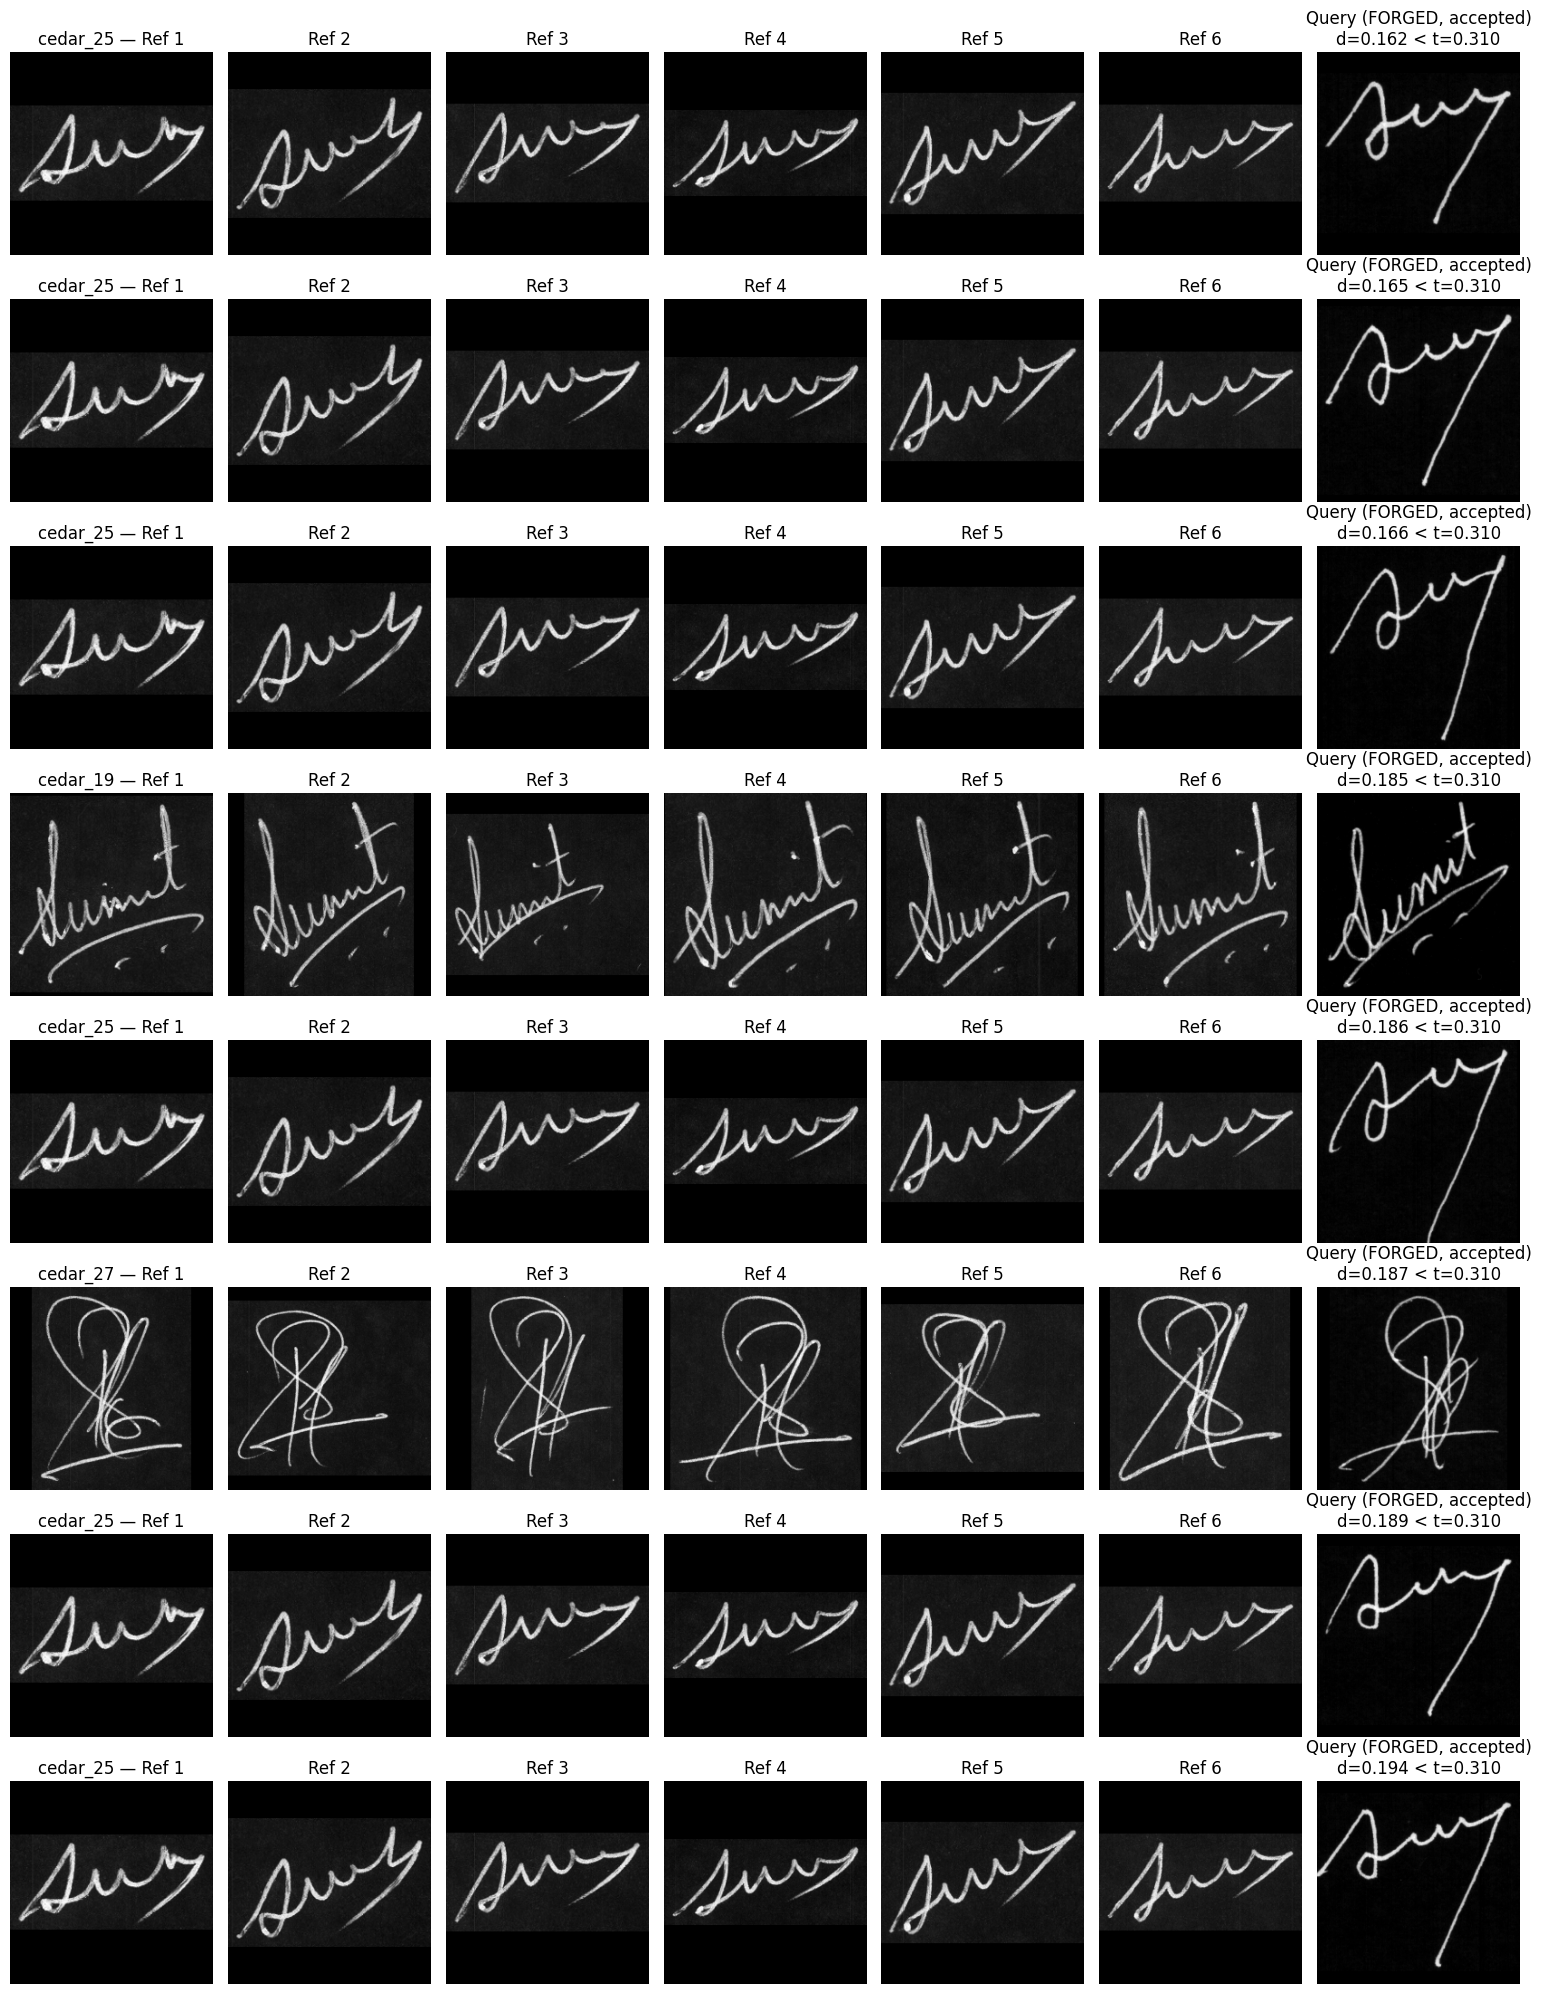

In [21]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Compute FP cases (6-reference protocol, threshold from val only)
# ------------------------------------------------------------------
nref = 6

val_ref, val_query = make_ref_query(val_df, nref, SEED)
val_dist, val_labels = distances(
    val_ref, embeddings(resnet_model, val_ref, BATCH_RESNET),
    val_query, embeddings(resnet_model, val_query, BATCH_RESNET)
)
t = threshold(val_dist, val_labels)

cedar_ref, cedar_query = make_ref_query(cedar_df, nref, SEED)
cedar_dist, cedar_labels = distances(
    cedar_ref, embeddings(resnet_model, cedar_ref, BATCH_RESNET),
    cedar_query, embeddings(resnet_model, cedar_query, BATCH_RESNET)
)

pred = (cedar_dist <= t).astype(int)
fp_mask = (pred == 1) & (cedar_labels == 0)
fp_indices = np.where(fp_mask)[0]

fp_df = cedar_query.reset_index(drop=True).iloc[fp_indices].copy()
fp_df["distance"] = cedar_dist[fp_indices]
fp_df["threshold"] = t

n_forged = int((cedar_labels == 0).sum())
print(f"Total FP cases: {len(fp_df)} out of {n_forged} forged samples")
print(f"FAR (False Positive Rate): {len(fp_df)/max(1,n_forged):.2%}")
display(fp_df[["writer_id", "path", "distance", "threshold"]])

# ------------------------------------------------------------------
# 2. Visualize: Ref 1..6 | Query (forged, wrongly accepted)
# ------------------------------------------------------------------
fp_sorted = fp_df.sort_values("distance").reset_index(drop=True)
n = min(8, len(fp_sorted))
n_ref_cols = nref

if n == 0:
    print("No FP cases to visualize.")
else:
    fig, axes = plt.subplots(n, n_ref_cols + 1, figsize=(2.2*(n_ref_cols+1), 2.5*n))
    if n == 1: axes = axes.reshape(1, -1)

    for i in range(n):
        row = fp_sorted.iloc[i]
        refs = cedar_ref[cedar_ref.writer_id == row.writer_id]

        for j in range(n_ref_cols):
            ref_img = load_signature(refs.iloc[j].path)
            axes[i, j].imshow(ref_img, cmap="gray")
            axes[i, j].set_title(f"{row.writer_id} — Ref {j+1}" if j == 0 else f"Ref {j+1}")
            axes[i, j].axis("off")

        query_img = load_signature(row.path)
        axes[i, n_ref_cols].imshow(query_img, cmap="gray")
        axes[i, n_ref_cols].set_title(f"Query (FORGED, accepted)\nd={row.distance:.3f} < t={row.threshold:.3f}")
        axes[i, n_ref_cols].axis("off")

    plt.tight_layout(); plt.show()

## With 10 Refrences

Total FP cases: 138 out of 1320 forged samples
FAR (False Positive Rate): 10.45%


,writer_id,path,distance,threshold
18,cedar_1,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.304281,0.35116
34,cedar_1,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.343495,0.35116
396,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.278455,0.35116
398,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.245033,0.35116
399,cedar_19,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.329495,0.35116
...,...,...,...,...
1822,cedar_52,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.283897,0.35116
1859,cedar_53,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.334853,0.35116
2039,cedar_8,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.349683,0.35116
2042,cedar_8,/root/.cache/kagglehub/datasets/shreelakshmigp...,0.339986,0.35116


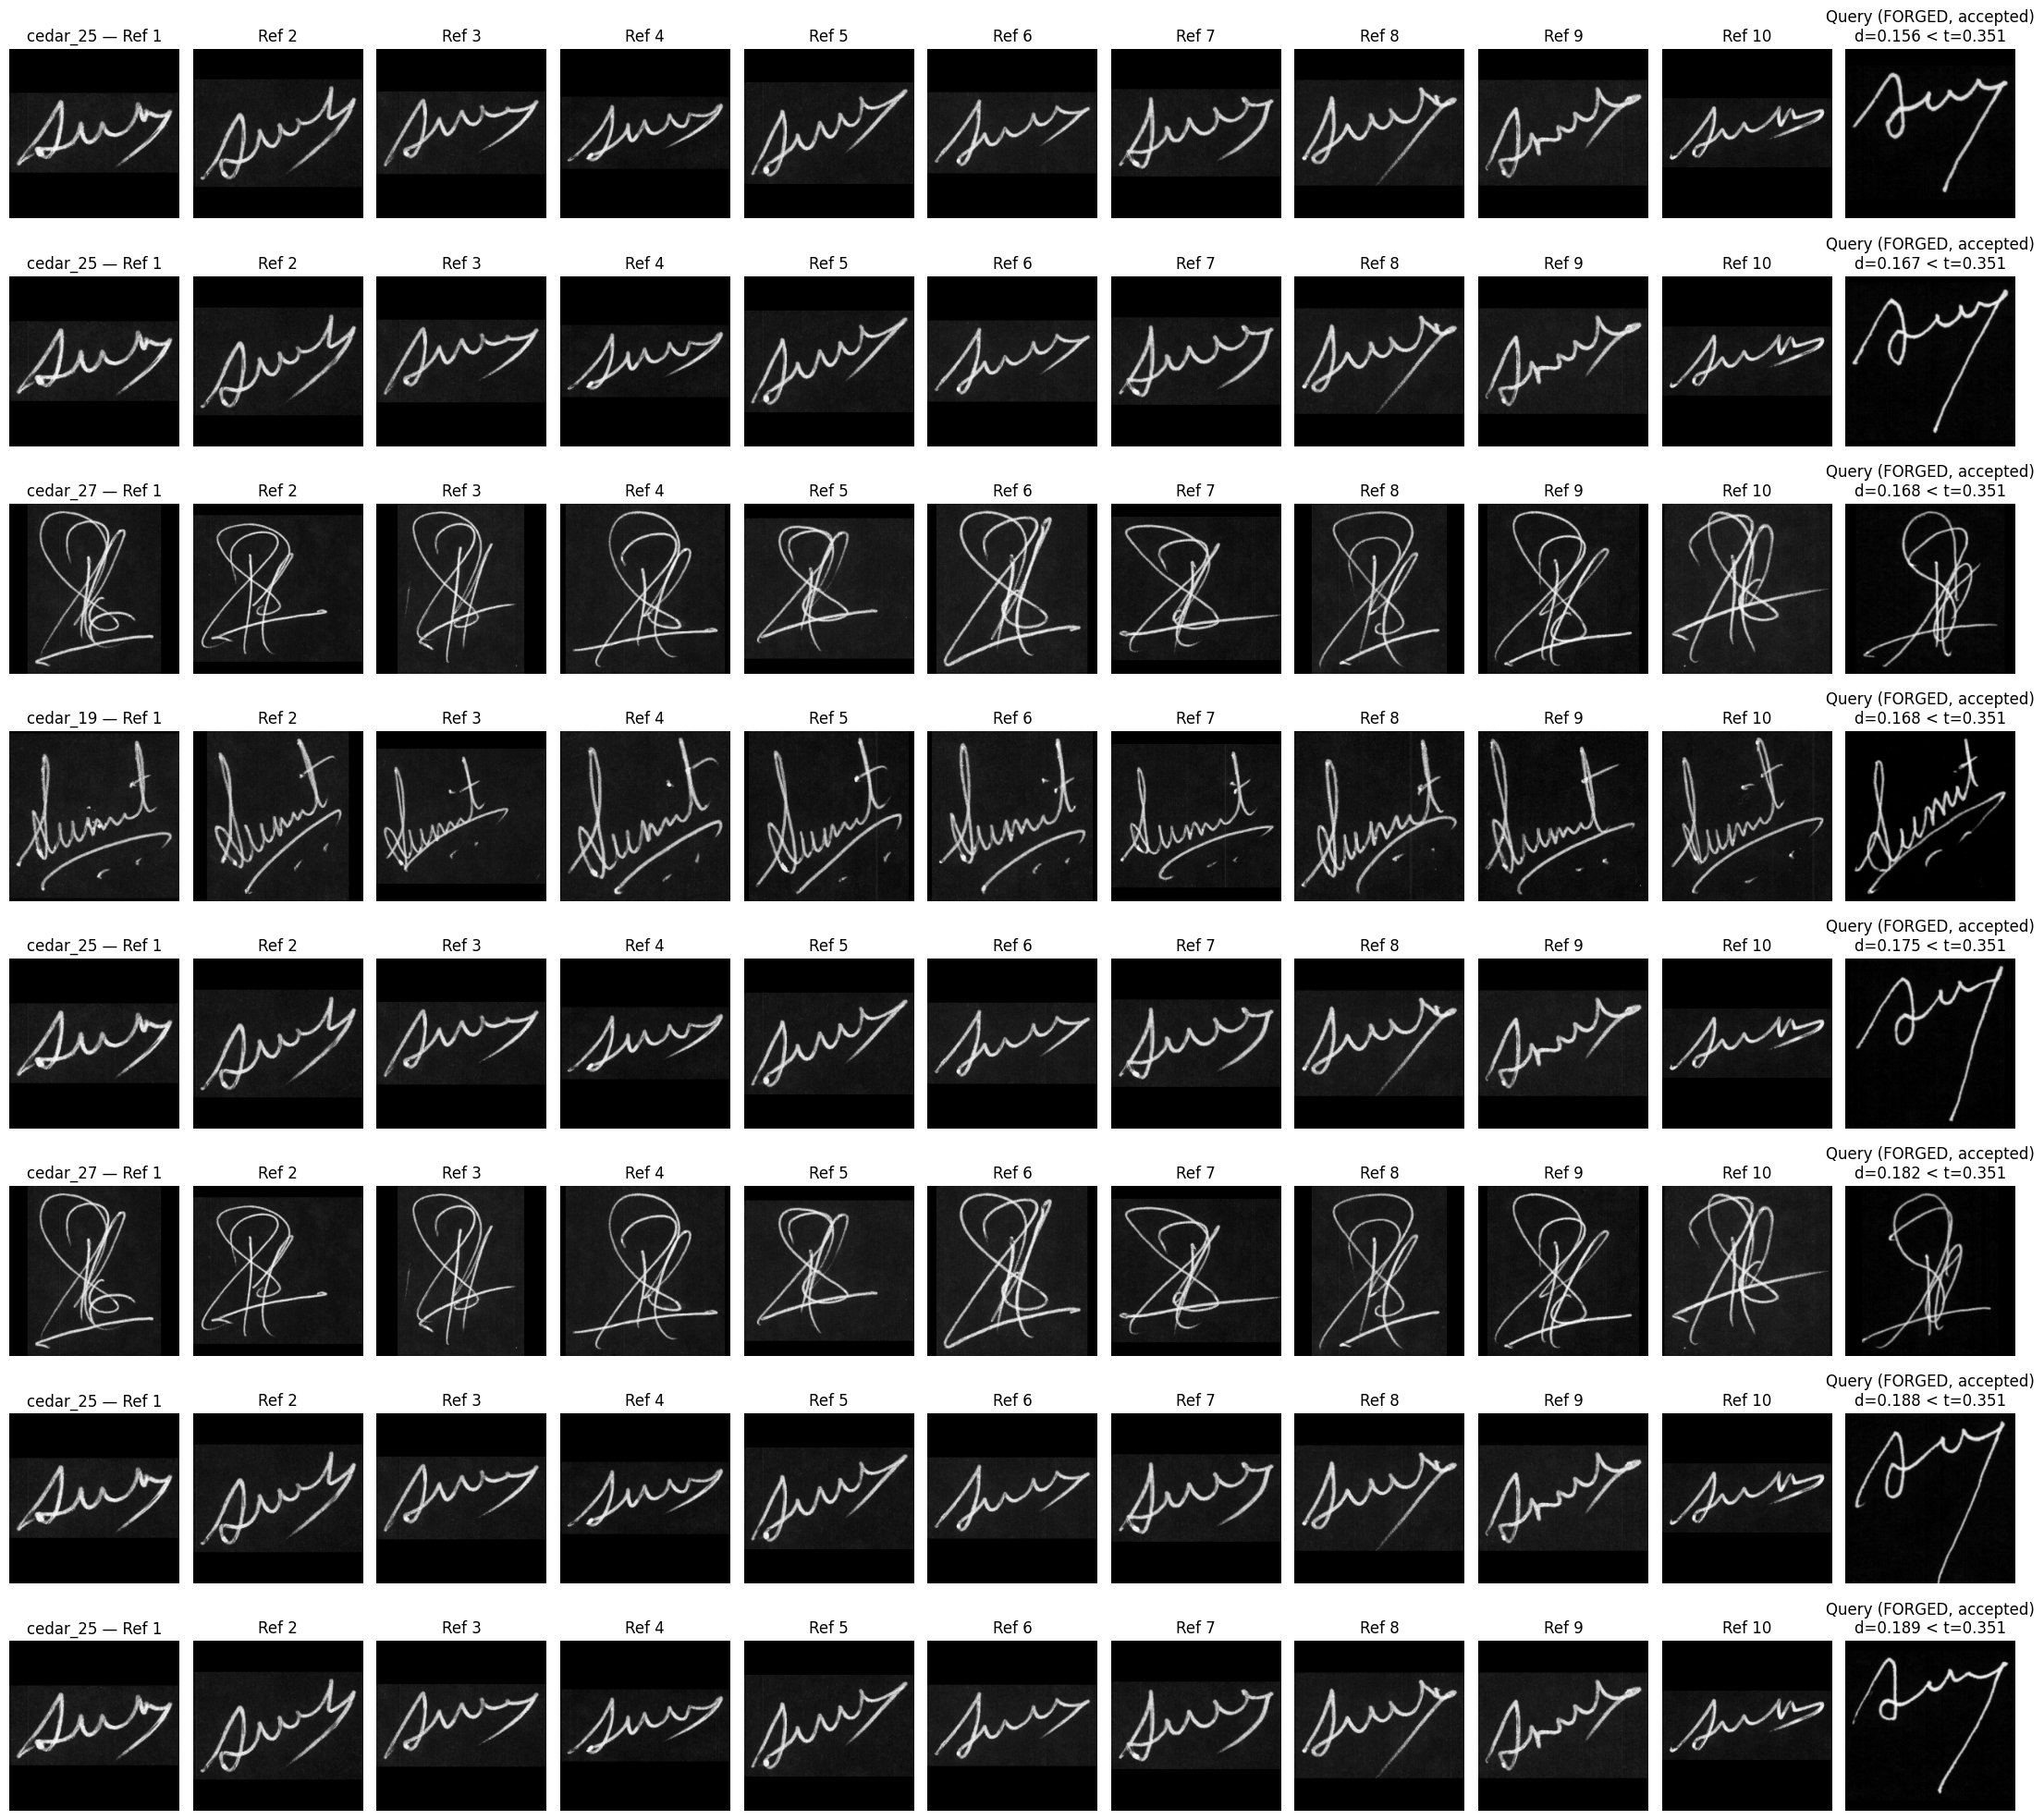

In [22]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Compute FP cases (10-reference protocol, threshold from val only)
# ------------------------------------------------------------------
nref = 10

val_ref, val_query = make_ref_query(val_df, nref, SEED)
val_dist, val_labels = distances(
    val_ref, embeddings(resnet_model, val_ref, BATCH_RESNET),
    val_query, embeddings(resnet_model, val_query, BATCH_RESNET)
)
t = threshold(val_dist, val_labels)

cedar_ref, cedar_query = make_ref_query(cedar_df, nref, SEED)
cedar_dist, cedar_labels = distances(
    cedar_ref, embeddings(resnet_model, cedar_ref, BATCH_RESNET),
    cedar_query, embeddings(resnet_model, cedar_query, BATCH_RESNET)
)

pred = (cedar_dist <= t).astype(int)
fp_mask = (pred == 1) & (cedar_labels == 0)
fp_indices = np.where(fp_mask)[0]

fp_df = cedar_query.reset_index(drop=True).iloc[fp_indices].copy()
fp_df["distance"] = cedar_dist[fp_indices]
fp_df["threshold"] = t

n_forged = int((cedar_labels == 0).sum())
print(f"Total FP cases: {len(fp_df)} out of {n_forged} forged samples")
print(f"FAR (False Positive Rate): {len(fp_df)/max(1,n_forged):.2%}")
display(fp_df[["writer_id", "path", "distance", "threshold"]])

# ------------------------------------------------------------------
# 2. Visualize: Ref 1..10 | Query (forged, wrongly accepted)
# ------------------------------------------------------------------
fp_sorted = fp_df.sort_values("distance").reset_index(drop=True)
n = min(8, len(fp_sorted))
n_ref_cols = nref

if n == 0:
    print("No FP cases to visualize.")
else:
    fig, axes = plt.subplots(n, n_ref_cols + 1, figsize=(2.0*(n_ref_cols+1), 2.5*n))
    if n == 1: axes = axes.reshape(1, -1)

    for i in range(n):
        row = fp_sorted.iloc[i]
        refs = cedar_ref[cedar_ref.writer_id == row.writer_id]

        for j in range(n_ref_cols):
            ref_img = load_signature(refs.iloc[j].path)
            axes[i, j].imshow(ref_img, cmap="gray")
            axes[i, j].set_title(f"{row.writer_id} — Ref {j+1}" if j == 0 else f"Ref {j+1}")
            axes[i, j].axis("off")

        query_img = load_signature(row.path)
        axes[i, n_ref_cols].imshow(query_img, cmap="gray")
        axes[i, n_ref_cols].set_title(f"Query (FORGED, accepted)\nd={row.distance:.3f} < t={row.threshold:.3f}")
        axes[i, n_ref_cols].axis("off")

    plt.tight_layout(); plt.show()

## 12. Save results

In [13]:
results_df.to_csv(RESULTS_DIR/"resnet50_2_3_6_10ref_results.csv",index=False)
with open(RESULTS_DIR/"resnet50_2_3_6_10ref_results.json","w") as f:
    json.dump(results_df.to_dict(orient="records"),f,indent=2)
print("Results saved in:",RESULTS_DIR)


Results saved in: /content/drive/MyDrive/signature_verification_final/results
